## Autonomous System 중간과제 
### - 차선 검출 및 Projection Matrix 분석

AI융합학부 20221445한지은

---

## 문제 1. Projection Matrix 해석

Projection Matrix는 3차원 공간의 점을 2차원 이미지 좌표로 변환하는 행렬로,
다음과 같이 표현된다.

$
P = K [R | t]
$

여기서 $K$는 카메라 내부 파라미터(intrinsic), $R$과 $t$는 카메라 외부 파라미터(extrinsic)를 의미한다.


#### (1) Intrinsic 파라미터 ($f_x, f_y, c_x, c_y$)의 의미

카메라 내부 파라미터 $K$는 카메라의 촬영 특성을 나타내며 다음과 같은 형태를 가진다.

$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
$

각 요소의 의미는 다음과 같다.

- $f_x, f_y$ : 픽셀 단위의 초점거리로, 값이 클수록 물체가 크게 확대되어 보인다.
  $x$축과 $y$축 방향의 초점거리가 다를 수 있어 각각 따로 정의한다.

- $c_x, c_y$ : 주점(principal point)으로, 카메라 광학 중심이 이미지 상에 투영된 좌표이다.
  이상적인 경우 이미지 중앙에 위치하지만 렌즈 조립 오차 등으로 인해 다를 수 있다.


#### (2) Extrinsic 파라미터 ($R, t$)의 역할

외부 파라미터는 카메라가 세계 좌표계에서 어디에 어떻게 놓여 있는지를 나타낸다.

- $R$ : 회전 행렬로, 세계 좌표계를 카메라 좌표계로 회전시킨다.
- $t$ : 이동 벡터로, 카메라의 세계 좌표계 내 위치를 나타낸다.

카메라의 위치나 방향이 바뀌면 $R$과 $t$가 달라지지만, 같은 카메라라면 $K$는 변하지 않는다.


#### (3) 3D 점을 이미지 좌표로 변환하는 수식

3D 점을 이미지 좌표로 변환하는 과정은 크게 두 단계로 나눌 수 있다.

**1) 세계 좌표계 → 카메라 좌표계**

$R$과 $t$를 이용해 세계 좌표계의 점을 카메라 기준 좌표로 바꾼다.

$
\begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix} = R \begin{bmatrix} X \\ Y \\ Z \end{bmatrix} + t
$

**2) 카메라 좌표계 → 이미지 좌표**

카메라 좌표계의 점에 내부 파라미터 $K$를 적용해 픽셀 좌표로 변환한다.
이 두 과정을 동차 좌표를 이용해 하나의 행렬식으로 표현하면 다음과 같다.

$
s
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
= K [R | t]
\begin{bmatrix}
X \\ Y \\ Z \\ 1
\end{bmatrix}
$

여기서 $s = Z_c$ 이고, 이를 $s$로 나누면 최종 픽셀 좌표를 구할 수 있다.

$
u = f_x \cdot \frac{X_c}{Z_c} + c_x, \quad v = f_y \cdot \frac{Y_c}{Z_c} + c_y
$

이때 $Z_c$로 나누는 과정이 포함되기 때문에,
멀리 있는 점일수록 이미지 중심 쪽으로 모여 보이는 원근 효과가 나타난다.

---
## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

Projection Matrix P0를 이용하여 임의의 3D 점을 이미지 좌표로 투영하였다.

KITTI sequence 09의 calib.txt에서 읽은 P0 행렬은 다음과 같다.

$
P_0 =
\begin{bmatrix}
707.09 & 0 & 601.89 & 0 \\
0 & 707.09 & 183.11 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
$


3D 점은 다음과 같이 생성하였다.
- X : 좌우 -3 ~ 3m (차선 범위)
- Y : 1.65m 고정 (KITTI 카메라 높이 — 도로 평면 위의 점을 생성하기 위해 고정)
- Z : 전방 5 ~ 30m

Projection Matrix P0:
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

투영된 점 수: 50
u 범위: 341.9 ~ 890.9
v 범위: 222.4 ~ 410.2


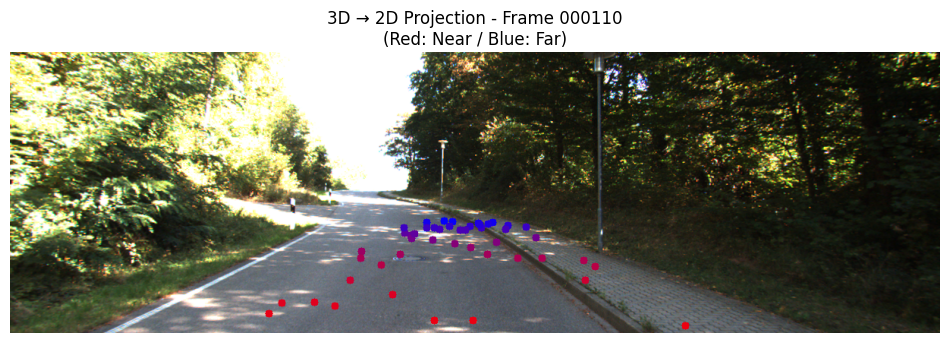

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# calib.txt에서 P0 행렬 읽기
calib_path = r"C:\SSWU\Autonomous_System\data_odometry_calib\dataset\sequences\09\calib.txt"

with open(calib_path, 'r') as f:
    for line in f:
        if line.startswith('P0'):
            P = np.array(line.strip().split()[1:], dtype=np.float64).reshape(3, 4)
            break

print("Projection Matrix P0:")
print(P)

# 도로 위의 점 생성
# KITTI 카메라 높이 약 1.65m → Y = 1.65로 고정
# X: 좌우 차선 범위 (-3 ~ 3m)
# Z: 전방 5 ~ 30m
np.random.seed(42)
n_points = 50
X = np.random.uniform(-3, 3, n_points)
Y = np.ones(n_points) * 1.65
Z = np.random.uniform(5, 30, n_points)

# 동차 좌표로 변환
points_3d = np.vstack([X, Y, Z, np.ones(n_points)])  # (4, N)

# 3D → 2D 투영
points_2d_h = P @ points_3d  # (3, N)
u = points_2d_h[0] / points_2d_h[2]
v = points_2d_h[1] / points_2d_h[2]

print(f"\n투영된 점 수: {n_points}")
print(f"u 범위: {u.min():.1f} ~ {u.max():.1f}")
print(f"v 범위: {v.min():.1f} ~ {v.max():.1f}")

# 원본 이미지 위에 시각화
img_path = r"C:\SSWU\Autonomous_System\data_odometry_color\dataset\sequences\09\image_2\000110.png"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# 이미지 범위 안에 있는 점만 표시
for i in range(n_points):
    if 0 <= u[i] < w and 0 <= v[i] < h:
        # Z값에 따라 색상 다르게 (가까울수록 빨강, 멀수록 파랑)
        color_ratio = (Z[i] - 5) / (30 - 5)
        color = (int(255 * (1 - color_ratio)), 0, int(255 * color_ratio))
        cv2.circle(img_rgb, (int(u[i]), int(v[i])), 5, color, -1)

plt.figure(figsize=(12, 4))
plt.imshow(img_rgb)
plt.title('3D → 2D Projection - Frame 000110\n(Red: Near / Blue: Far)')
plt.axis('off')
plt.show()

#### 결과 해석

투영 결과를 보면 가까운 점(빨강)은 이미지 아래쪽에,
먼 점(파랑)은 이미지 위쪽 소실점 방향으로 수렴하는 것을 볼 수 있다.
또한 가까울수록 좌우로 넓게 퍼지고 멀어질수록 좁아지면서
전체적으로 사다리꼴 형태를 이루는데, 이는 원근 투영의 자연스러운 결과이다.
Y값을 고정했기 때문에 점들이 실제 도로 위에 올라간 것도 확인할 수 있다.

이 결과는 카메라 투영의 특성과 다음과 같이 일치한다.
- **원근감**: 멀리 있는 점($Z$가 클수록)일수록 이미지 중심으로 수렴하는데,
  이는 $u = f_x \cdot \frac{X}{Z} + c_x$ 수식에서 $Z$가 커질수록 $\frac{X}{Z}$가 작아지기 때문이다.
- **소실점**: 먼 점들이 이미지 중앙 상단으로 모이는데,
  이 위치가 바로 주점 $(c_x, c_y)$ 근방의 소실점에 해당한다.
- **사다리꼴 형태**: 도로 위의 평행한 점들이 이미지에서 사다리꼴로 보이는 것은
  3D 공간의 평행선이 투영 후 소실점으로 수렴하는 원근 투영의 특성과 일치한다.

---
## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터의 각 행은 3×4 변환 행렬로, 오른쪽 열($t_x, t_y, t_z$)이
해당 프레임에서의 카메라 위치를 나타낸다. 이를 추출하여 초기 프레임을 기준 좌표계로
설정한 후 3D 궤적을 시각화하였다.

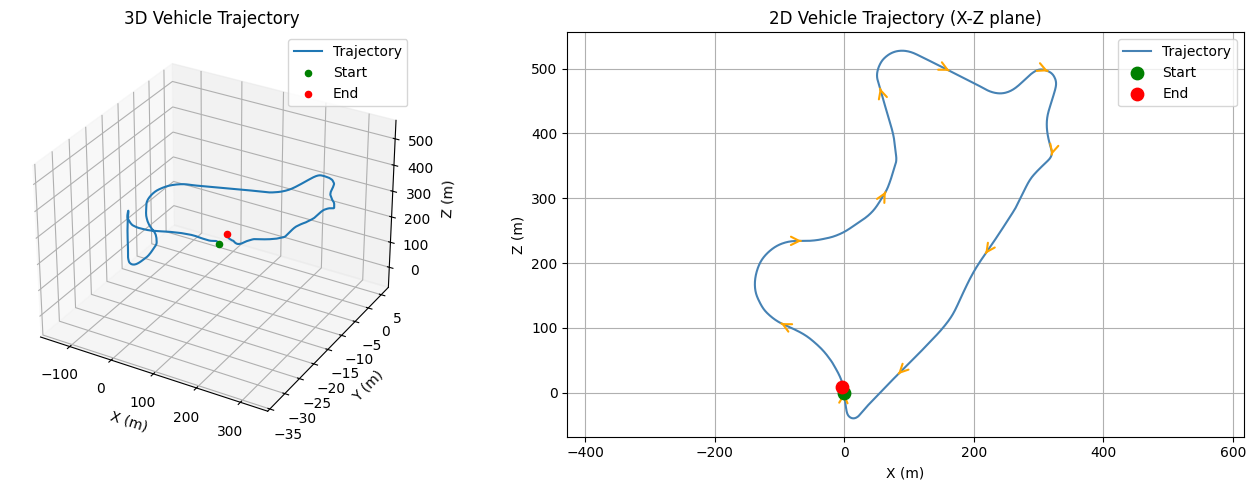

X축 이동 범위: -137.8 ~ 327.2 m (총 465.0 m)
Y축 이동 범위: -32.9 ~ 5.0 m (총 38.0 m)
Z축 이동 범위: -39.8 ~ 527.8 m (총 567.6 m)
평균 속도: 10.72 m/s (38.60 km/h)
최대 속도: 15.45 m/s (55.62 km/h)
최소 속도: 2.89 m/s (10.40 km/h)


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# pose 파일 로드
pose_path = r"C:\SSWU\Autonomous_System\data_odometry_poses\dataset\poses\09.txt"
poses = np.loadtxt(pose_path)

# 각 프레임의 위치(tx, ty, tz) 추출
x = poses[:, 3]
y = poses[:, 7]
z = poses[:, 11]

# 초기 프레임을 기준 좌표계로 설정
x = x - x[0]
y = y - y[0]
z = z - z[0]

fig = plt.figure(figsize=(14, 5))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x, y, z, label='Trajectory')
ax1.scatter(x[0], y[0], z[0], c='green', label='Start')
ax1.scatter(x[-1], y[-1], z[-1], c='red', label='End')
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('3D Vehicle Trajectory')
ax1.legend()

# 2D plot (X-Z 평면)
ax2 = fig.add_subplot(122)
ax2.plot(x, z, color='steelblue', label='Trajectory')

# 진행 방향 화살표
step = len(x) // 10
for i in range(0, len(x) - step, step):
    ax2.annotate('',
        xy=(x[i+1], z[i+1]),
        xytext=(x[i], z[i]),
        arrowprops=dict(arrowstyle='->', color='orange', lw=1.5, mutation_scale=15))

ax2.scatter(x[0], z[0], c='green', s=80, zorder=5, label='Start')
ax2.scatter(x[-1], z[-1], c='red', s=80, zorder=5, label='End')
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('2D Vehicle Trajectory (X-Z plane)')
ax2.legend()
ax2.axis('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"X축 이동 범위: {x.min():.1f} ~ {x.max():.1f} m (총 {x.max()-x.min():.1f} m)")
print(f"Y축 이동 범위: {y.min():.1f} ~ {y.max():.1f} m (총 {y.max()-y.min():.1f} m)")
print(f"Z축 이동 범위: {z.min():.1f} ~ {z.max():.1f} m (총 {z.max()-z.min():.1f} m)")

distances = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
speeds = distances * 10.0

print(f"평균 속도: {speeds.mean():.2f} m/s ({speeds.mean()*3.6:.2f} km/h)")
print(f"최대 속도: {speeds.max():.2f} m/s ({speeds.max()*3.6:.2f} km/h)")
print(f"최소 속도: {speeds.min():.2f} m/s ({speeds.min()*3.6:.2f} km/h)")

#### 차량의 이동 방향과 속도 분석

##### 이동 방향
3D 궤적에서 Y축 변화가 상대적으로 작아 대체로 평탄한 도로를 주행한 것으로 보인다.
2D 궤적의 화살표 방향을 보면 차량은 출발 지점에서 Z축 방향(전방)으로 출발한 뒤
X축으로 여러 번 방향을 바꾸며 큰 루프를 그리는 경로를 주행하였다.
시작점과 종료점이 거의 같은 위치에 있어 출발 지점 근방으로 돌아온 것을 확인할 수 있으며,
총 이동 범위는 X축 약 465m, Y축 약 38m, Z축 약 568m였다.

##### 이동 속도
프레임 간 3D 거리를 계산하고 촬영 주기(10Hz)를 적용하여 속도를 추정하였다.
평균 속도는 약 38.60 km/h, 최대 속도는 55.62 km/h, 최소 속도는 10.40 km/h로 나타났다.
전반적으로 시가지 주행 속도 범위에 해당하며,
최소 속도 구간은 교차로나 커브 구간에서의 감속에 의한 것으로 추정된다.

---

## 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역(mask)을 이용하여 차선 후보를 추출하고,
이를 projection matrix와 연관 지어 해석하였다.

#### 차선 후보 추출

Bayesian 분류로 생성된 이진 마스크에 Canny 엣지 검출을 적용한 후,
Hough Transform으로 차선 후보 선분을 추출하였다.
초기에는 307개의 선분이 검출되었으나, 파라미터 조정
(threshold: 50→100, minLineLength: 50→100)으로 133개로 줄였다.
다만 Bayesian 마스크 경계가 울퉁불퉁하다 보니
나무나 풀숲 경계도 일부 차선으로 잡히는 한계가 있었다.


검출된 차선 후보 수: 133


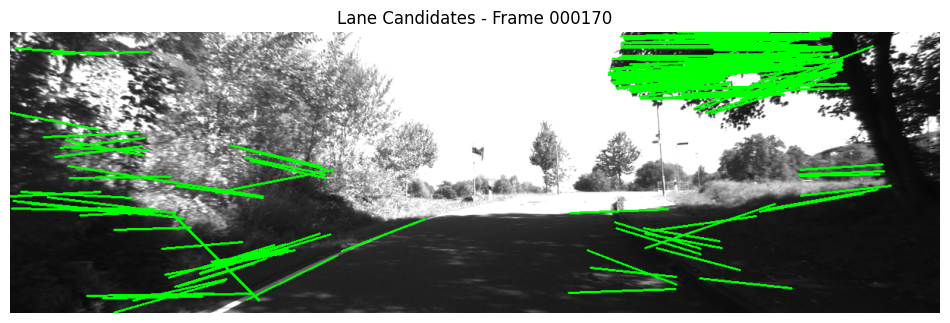

In [22]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# 경로 설정
mask_path = Path(r"C:\SSWU\Autonomous_System\outputs\bayes_road_09\mask_000170.png")
img_path = Path(r"D:\jieunee\data_odometry_gray\dataset\sequences\09\image_0\000170.png")

# 이미지 로드
mask = cv2.imread(str(mask_path), 0)
original = cv2.imread(str(img_path), 0)
original_color = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)

# 엣지 검출
edges = cv2.Canny(mask, 50, 150)

# Hough Transform으로 차선 후보 선분 검출
# threshold, minLineLength 조정으로 노이즈 선분 감소 (307개 → 133개)
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi/180,
    threshold=100,
    minLineLength=100,
    maxLineGap=20
)

# 차선 후보 그리기
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(original_color, (x1, y1), (x2, y2), (0, 255, 0), 2)
    print(f"검출된 차선 후보 수: {len(lines)}")
else:
    print("차선 후보 없음")

# 결과 저장
output_path = Path(r"C:\SSWU\Autonomous_System\outputs\bayes_road_09\lane_000170.png")
cv2.imwrite(str(output_path), original_color)

# 결과 시각화
plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(original_color, cv2.COLOR_BGR2RGB))
plt.title('Lane Candidates - Frame 000170')
plt.axis('off')
plt.show()

#### (1) 이미지 좌표에서 검출된 차선의 카메라 좌표계 의미

이미지에서 검출된 차선은 픽셀 좌표 $(u, v)$로 표현된다.
Projection Matrix $P$가 3D 점을 2D로 투영하는 역할을 하므로,
반대로 이미지의 차선은 실제 도로 위의 3D 직선이 투영된 결과로 볼 수 있다.
즉, 이미지에서 보이는 선 하나하나가 카메라 앞쪽(Z축 방향)으로
뻗어 있는 3D 직선에 대응된다.

#### (2) 도로가 평면일 때 차선의 기하적 특성

도로가 평면이라고 가정하면 카메라 좌표계에서 $Y = 0$으로 고정할 수 있다.
이 경우 차선은 $X$축(좌우)과 $Z$축(전방)으로 이루어진 평면 위의 직선이 된다.
실제로 평행한 두 차선은 3D 공간에서는 평행하지만,
카메라로 찍으면 원근 효과 때문에 멀어질수록 가까워지다가
소실점 한 곳으로 수렴하는 것처럼 보인다.
이는 문제 2에서 확인한 원근 투영의 특성과 동일한 원리이다.

#### (3) Projection Matrix와 기울기, 소실점의 관계

Projection Matrix $P = K[R|t]$에서 초점거리 $f_x, f_y$가 클수록
원근 효과가 강해져서 차선이 더 빠르게 소실점으로 수렴한다.
sequence 09의 경우 $f_x = 707.09$, $c_x = 601.89$, $c_y = 183.11$로,
소실점은 주점 근방인 이미지 가로 중앙 약간 오른쪽,
세로 상단 1/3 지점 부근에 위치하게 된다.

---

## 문제 5. 실패 구간 분석

Bayesian 분류 결과 중 차선 검출이 잘 되지 않은 구간 3개를 선택하여 분석하였다.
아래 궤적 그래프에서 빨간 X 표시가 각 실패 구간의 위치이다.

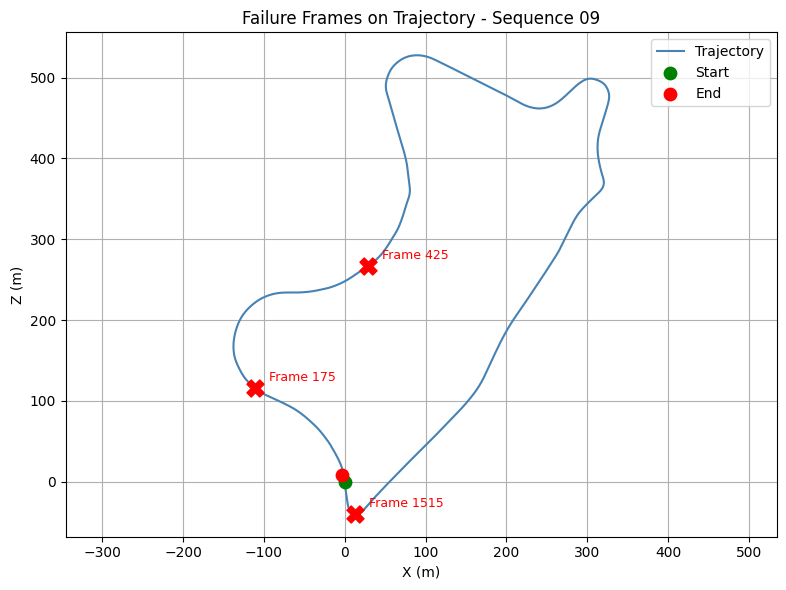

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pose 파일 로드
pose_path = r"C:\SSWU\Autonomous_System\data_odometry_poses\dataset\poses\09.txt"
poses = np.loadtxt(pose_path)

x = poses[:, 3]
z = poses[:, 11]
x = x - x[0]
z = z - z[0]

# 실패 구간 프레임 번호
fail_frames = [175, 425, 1515]

plt.figure(figsize=(8, 6))
plt.plot(x, z, color='steelblue', label='Trajectory')
plt.scatter(x[0], z[0], c='green', s=80, zorder=5, label='Start')
plt.scatter(x[-1], z[-1], c='red', s=80, zorder=5, label='End')

# 실패 구간 표시
for f in fail_frames:
    plt.scatter(x[f], z[f], c='red', marker='X', s=150, zorder=6)
    plt.annotate(f'Frame {f}', (x[f], z[f]), textcoords="offset points", xytext=(10, 5), fontsize=9, color='red')

plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Failure Frames on Trajectory - Sequence 09')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()


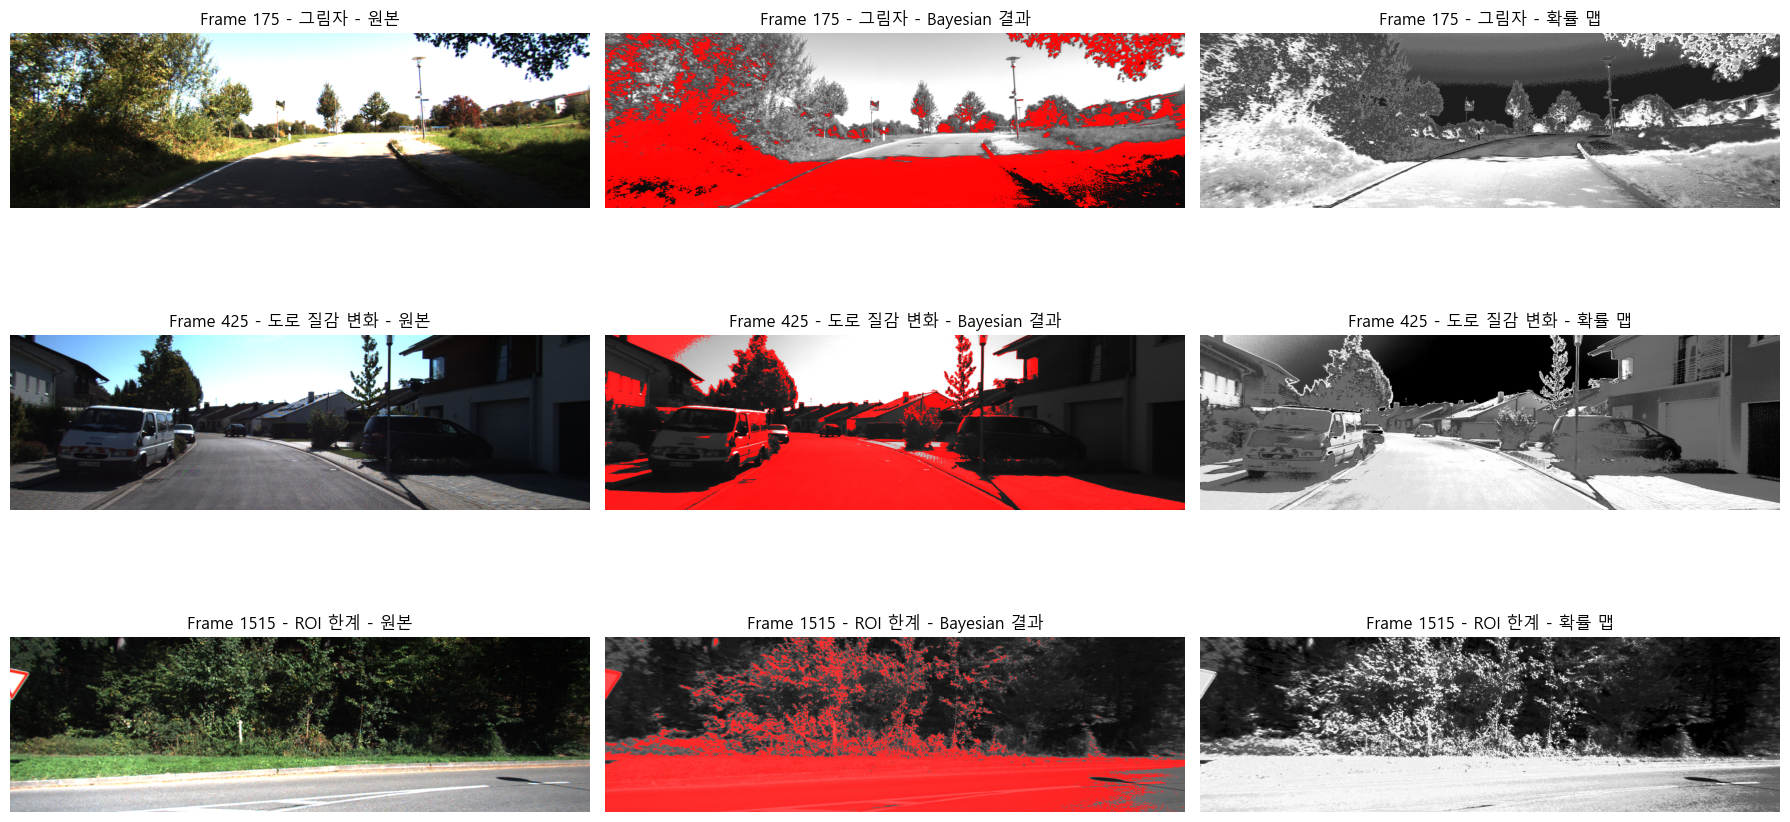

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

frames = [
    ('000175', 'Frame 175 - 그림자'),
    ('000425', 'Frame 425 - 도로 질감 변화'),
    ('001515', 'Frame 1515 - ROI 한계'),
]

for i, (stem, title) in enumerate(frames):
    # 컬러 원본
    color_img = mpimg.imread(rf"C:\SSWU\Autonomous_System\data_odometry_color\dataset\sequences\09\image_2\{stem}.png")
    axes[i][0].imshow(color_img)
    axes[i][0].set_title(f'{title} - 원본')
    axes[i][0].axis('off')

    # overlay
    overlay_img = mpimg.imread(rf"C:\SSWU\Autonomous_System\outputs\bayes_road_09\overlay_{stem}.png")
    axes[i][1].imshow(overlay_img, cmap='gray')
    axes[i][1].set_title(f'{title} - Bayesian 결과')
    axes[i][1].axis('off')

    # prob
    prob_img = mpimg.imread(rf"C:\SSWU\Autonomous_System\outputs\bayes_road_09\prob_{stem}.png")
    axes[i][2].imshow(prob_img, cmap='gray')
    axes[i][2].set_title(f'{title} - 확률 맵')
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()

#### (1) Frame 175 — 그림자로 인한 분류 실패

컬러 원본 이미지를 보면 나무 그림자가 도로 위에 짙게 드리워져 있다.
Bayesian 분류기가 어두운 픽셀을 도로로 학습한 결과,
그림자가 드리운 가까운 도로는 검출되었지만
그림자가 없어 밝게 보이는 먼쪽 도로는 배경으로 잘못 분류되었다.
확률 맵에서도 가까운 도로는 밝게, 먼쪽 도로는 어둡게 나타나
그림자로 인해 도로일 확률이 낮게 계산된 것을 확인할 수 있다.

- **주요 원인**: 그림자로 인한 조명 변화

#### (2) Frame 425 — 보도블록으로 인한 도로 질감 변화

컬러 원본 이미지를 보면 오른쪽에 보도블록 인도가 있는데,
overlay 결과에서 인도까지 도로로 잘못 분류된 것을 확인할 수 있다.
확률 맵에서도 도로 중앙과 오른쪽 보도블록의 밝기가 비슷하게 나타나,
두 영역의 도로일 확률이 유사하게 계산된 것을 알 수 있다.
보도블록은 아스팔트와 질감이 다르지만 밝기가 비슷하여
픽셀 밝기만을 기준으로 분류하는 Bayesian 분류기가 구분하지 못한 것으로 보인다.

- **주요 원인**: 도로 질감 변화 (아스팔트 vs 보도블록)

#### (3) Frame 1515 — 차량 회전으로 인한 ROI 한계

컬러 원본 이미지를 보면 차량이 교차로에서 회전한 상태로,
실제 도로가 이미지 아래쪽 좌우로 펼쳐져 있고 앞쪽은 풀숲이다.
사다리꼴 ROI는 항상 이미지 아래쪽 중앙에 도로가 있다고 가정하기 때문에,
차량이 회전하여 도로 방향이 바뀐 경우에는 실제 도로를 올바르게 커버하지 못한다.
확률 맵에서도 실제 도로(아래쪽 좌우)는 밝게 나타났지만
앞쪽 풀숲도 중간 밝기로 나타나 ROI 가정의 한계가 드러난다.

- **주요 원인**: 차량 회전으로 인한 ROI 가정의 한계